In [1]:
import dinkum
from dinkum.vfg import Gene, Receptor, GeneStateInfo
from dinkum.vfn import Tissue, get_tissue

from dinkum import vfg2
from dinkum.vfg2 import (Growth, Decay, LinearCombination, GeneTimecourse, LogisticActivator,
                         LogisticMultiRepressor, run_lmfit, LogisticRepressor, calc_response_1d, calc_response_2d)

from scipy.optimize import curve_fit
from lmfit import minimize, Parameters
import numpy as np
import matplotlib.pyplot as plt

# Custom activation logic - TRIAL 3


In [2]:
dinkum.reset()

x = Gene(name='X')
y = Gene(name='Y')
z = Gene(name='Z')
o = Gene(name='out')
oX = Gene(name='oX')
oY = Gene(name='oY')
m = Tissue(name='M')

# @CTB note: check parameters, etc.
x.custom2(Decay(start_time=1, rate=1.2, initial_level=100, tissue=m))
y.custom2(Growth(start_time=1, rate=0.5, initial_level=0, tissue=m))
z.custom2(GeneTimecourse(start_time=2, tissue=m, values=[100, 200, 300]))

linear_combination = LinearCombination(weights=[-0.5, .33, .33], gene_names=['X', 'Y', 'Z'])
o.custom2(linear_combination)

fit_decay = Decay(start_time=1, rate=1, initial_level=1, tissue=m)
oX.custom2(fit_decay)

fit_growth = Growth(start_time=1, rate=0, initial_level=100, tissue=m)
oY.custom2(fit_growth)

fit_values = [0, 100, 0,
              100, 100, 0,
              83, 83, 50,
              69, 69, 75,
              57, 57, 87]

run_lmfit(1, 5, fit_values, [o, oX, oY])
p = Parameters()
linear_combination.get_params(p)
fit_decay.get_params(p)
fit_growth.get_params(p)

display_fn, conc_df, active_df = dinkum.run_and_display_df(stop=5)

initializing: dinkum v0.5.0
start=1 stop=5
fit message: Fit succeeded. Could not estimate error-bars.
fit values:
	out_wX: fit=0.999805120295445 (was: -0.5)
	out_wY: fit=0.0013534156840044886 (was: 0.33)
	out_wZ: fit=-0.009421867040707355 (was: 0.33)
	oX_decay: fit=1.1484236048903436 (was: 1)
	oX_initial: fit=105.93001005666628 (was: 1)
	oY_growth: fit=0.0 (was: 0)
	oY_initial: fit=4.21313984878335e-16 (was: 100)
start=1 stop=5


In [3]:
dinkum.reset()

x = Gene(name='X')
y = Gene(name='Y')
z = Gene(name='Z')
o = Gene(name='out')
o2 = Gene(name='out2')

#oX = Gene(name='oX')
#oY = Gene(name='oY')
m = Tissue(name='M')

# @CTB note: check parameters, etc.
x.custom2(Decay(start_time=1, rate=1.2, initial_level=100, tissue=m))
y.custom2(Growth(start_time=1, rate=0.5, initial_level=0, tissue=m))
z.custom2(GeneTimecourse(start_time=2, tissue=m, values=[100, 200, 300]))

linear_combination = LinearCombination(weights=[-0.5, .33, .33], gene_names=['X', 'Y', 'Z'])
o.custom2(linear_combination)

o2.custom2(LinearCombination(weights=[-0.5, .33, .33], gene_names=['X', 'Y', 'Z']))

fit_values = [0,
              100,
              83,
              69,
              100,]

run_lmfit(1, 5, fit_values, [o])
p = Parameters()
linear_combination.get_params(p)
fit_decay.get_params(p)
fit_growth.get_params(p)

display_fn, conc_df, active_df = dinkum.run_and_display_df(stop=5)

initializing: dinkum v0.5.0
start=1 stop=5
fit message: Fit succeeded.
fit values:
	out_wX: fit=1.0191251732450013 (was: -0.5)
	out_wY: fit=-1.0140516200357155 (was: 0.33)
	out_wZ: fit=1.2584454548304578 (was: 0.33)
start=1 stop=5


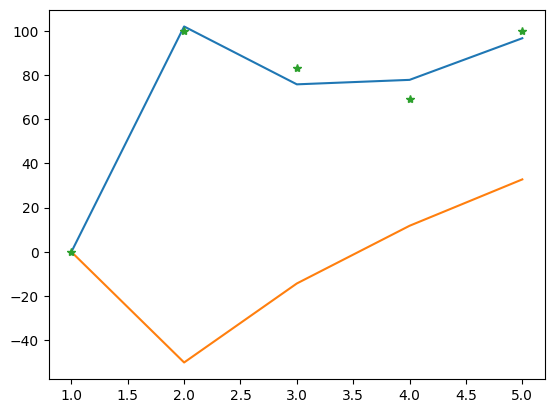

In [4]:
plt.plot(conc_df.index, conc_df.out)
plt.plot(conc_df.index, conc_df.out2)
plt.plot(conc_df.index, fit_values, '*')

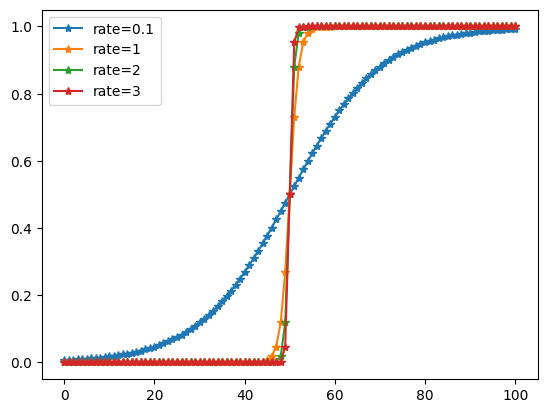

In [5]:
# logistic function
import math

def logistic(level, *, rate=1, midpoint=50):
    expon = -rate * (level - midpoint)
    denom = 1 + math.exp(expon)
    return 1 / denom

inp = list(range(0, 101))

for rate in (.1, 1, 2, 3):
    for midpoint in 50, :
        out = [ logistic(x, rate=rate, midpoint=midpoint) for x in inp ]
        plt.plot(inp, out, '-*', label=f'rate={rate}')

#foo = [ logistic(x, rate=1) for x in inp

plt.legend()


initializing: dinkum v0.5.0
start=1 stop=5
fit values:
	out_rate: fit=82.0 (was: 11)
	out_midpoint: fit=47.0 (was: 50.0)


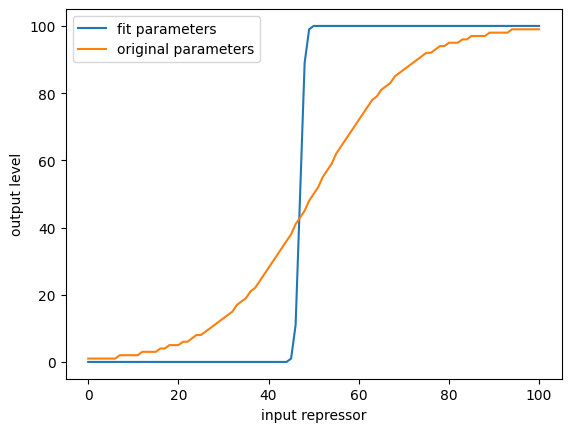

In [6]:
dinkum.reset()

#x = Gene(name='X')
#y = Gene(name='Y')
z = Gene(name='Z')
o = Gene(name='out')
o2 = Gene(name='out2')

m = Tissue(name='M')

# @CTB note: check parameters, etc.
z.custom2(GeneTimecourse(start_time=1, tissue=m, values=[33, 45, 49, 100, 100]))

logit = LogisticActivator(activator_name='Z')
o.custom2(logit)
o2.custom2(LogisticActivator(activator_name='Z'))

fit_values = [0, 0, 0, 100, 100]

run_lmfit(1, 5, fit_values, [o,], method='brute')
p = Parameters()
logit.get_params(p)

xvals, yvals_fit = calc_response_1d(timepoint=2, target_gene_name='out', variable_gene_name='Z')
xvals, yvals_nofit = calc_response_1d(timepoint=2, target_gene_name='out2', variable_gene_name='Z')

plt.plot(xvals, yvals_fit, label='fit parameters')
plt.plot(xvals, yvals_nofit, label='original parameters')
plt.xlabel('input repressor')
plt.ylabel('output level')
plt.legend()

initializing: dinkum v0.5.0
start=1 stop=5
fit values:
	out_rate: fit=17.0 (was: 100)
	out_midpoint: fit=70.0 (was: 50.0)


Text(0, 0.5, 'output level')

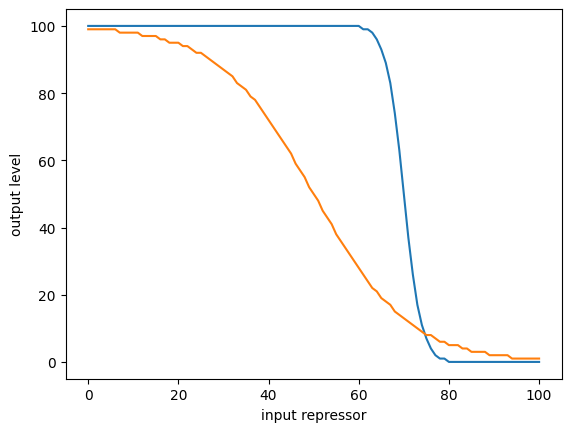

In [7]:
dinkum.reset()

x = Gene(name='X')
#y = Gene(name='Y')
z = Gene(name='Z')
o = Gene(name='out')
o2 = Gene(name='out2')

m = Tissue(name='M')
x.is_present(where=m, start=1)

# @CTB note: check parameters, etc.
z.custom2(GeneTimecourse(start_time=1, tissue=m, values=[20, 40, 60, 80, 100], normalize=False))

logit = LogisticRepressor(activator_name='X', repressor_name='Z', rate=100)
o.custom2(logit)
o2.custom2(LogisticRepressor(activator_name='X', repressor_name='Z'))

fit_values = [0, 100, 100, 100, 0]

run_lmfit(1, 5, fit_values, [o,], method='brute')


xvals, yvals_fit = calc_response_1d(timepoint=2, target_gene_name='out', variable_gene_name='Z',
                                fixed_gene_states={ 'X': GeneStateInfo(100, True) })
xvals, yvals_nofit = calc_response_1d(timepoint=2, target_gene_name='out2', variable_gene_name='Z',
                                fixed_gene_states={ 'X': GeneStateInfo(100, True) })

plt.plot(xvals, yvals_fit, label='fit parameters')
plt.plot(xvals, yvals_nofit, label='original parameters')
plt.xlabel('input repressor')
plt.ylabel('output level')

initializing: dinkum v0.5.0


Text(0, 0.5, 'output level')

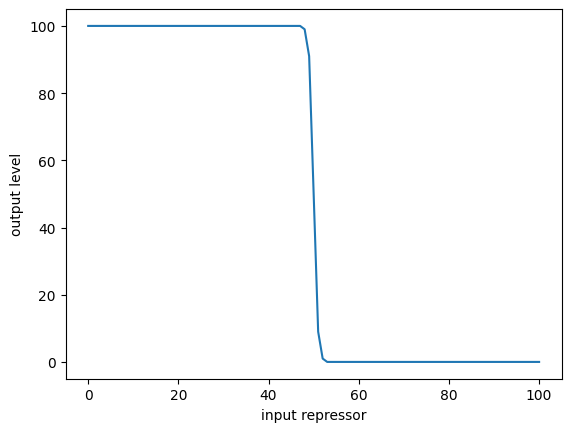

In [8]:
dinkum.reset()

x = Gene(name='X')
#y = Gene(name='Y')
z = Gene(name='Z')
o = Gene(name='out')
o2 = Gene(name='out2')

m = Tissue(name='M')
x.is_present(where=m, start=1)

# @CTB note: check parameters, etc.
z.custom2(GeneTimecourse(start_time=1, tissue=m, values=[20, 40, 60, 80, 100], normalize=False))

logit = LogisticRepressor(activator_name='X', repressor_name='Z', rate=100, midpoint=50)
o.custom2(logit)

xvals, yvals = calc_response_1d(timepoint=2, target_gene_name='out', variable_gene_name='Z',
                                fixed_gene_states={ 'X': GeneStateInfo(100, True) })

plt.plot(xvals, yvals)
plt.xlabel('input repressor')
plt.ylabel('output level')

initializing: dinkum v0.5.0


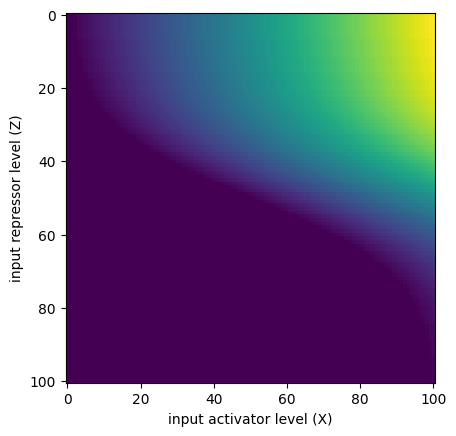

In [9]:
dinkum.reset()

x = Gene(name='X')
z = Gene(name='Z')
o = Gene(name='out')
o2 = Gene(name='out2')

m = Tissue(name='M')
x.is_present(where=m, start=1)

# @CTB note: check parameters, etc.
z.custom2(GeneTimecourse(start_time=1, tissue=m, values=[20, 40, 60, 80, 100], normalize=False))

logit = LogisticMultiRepressor(activator_name='X', repressor_names=['Z'], weights=[1.0], rate=11, midpoint=50)
o.custom2(logit)

arr = calc_response_2d(timepoint=2, target_gene_name='out', x_gene_name='X', y_gene_name='Z')

plt.imshow(arr, cmap='viridis', interpolation='nearest')
plt.xlabel('input activator level (X)')
plt.ylabel('input repressor level (Z)')
plt.show()